# 🛍️ Fashion Retail Sales Insights (Simulated Real-Time)
 This notebook processes a large fashion dataset using PySpark, simulates a Kafka streaming use-case, and builds insights with rating, seasonality, and payment behavior.


In [1]:
import os
import sys

os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] += os.pathsep + "C:\\hadoop\\bin"

# Set python executable path
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Simulated Kafka Integration
# 🧾 Kafka Producer (Simulating real-time ingest)

In [ ]:
from kafka import KafkaProducer
import pandas as pd
import time
import json

producer = KafkaProducer(bootstrap_servers='localhost:9092',
                         value_serializer=lambda v: json.dumps(v).encode('utf-8'))

df = pd.read_csv("Fashion_Retail_Sales.csv")
for _, row in df.iterrows():
    record = row.to_dict()
    producer.send("fashion-sales", record)
    time.sleep(0.5)

# Kafka Consumer via PySpark Structured Streaming

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import from_json, col
from pyspark.sql.types import StructType, StringType, FloatType

spark = SparkSession.builder.appName("StreamingRetail").getOrCreate()

schema = StructType().add("product", StringType()).add("price", FloatType())

df = spark.readStream.format("kafka").option("kafka.bootstrap.servers", "localhost:9092").option("subscribe", "fashion-sales").load()

json_df = df.selectExpr("CAST(value AS STRING)").select(from_json("value", schema).alias("data")).select("data.*")

query = json_df.writeStream.format("parquet").option("path", "output/streaming_output").option("checkpointLocation", "/tmp/checkpoints").start()

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, month, when

In [3]:
spark = SparkSession.builder.appName("FashionRetailAnalysis").getOrCreate()

In [4]:
spark

In [6]:
df = spark.read.option("header", True).csv("Fashion_Retail_Sales.csv")
df.show(5)
df.printSchema()

+---------------------+--------------+---------------------+-------------+-------------+--------------+
|Customer Reference ID|Item Purchased|Purchase Amount (USD)|Date Purchase|Review Rating|Payment Method|
+---------------------+--------------+---------------------+-------------+-------------+--------------+
|                 4018|       Handbag|                 4619|   05-02-2023|         NULL|   Credit Card|
|                 4115|         Tunic|                 2456|   11-07-2023|            2|   Credit Card|
|                 4019|      Tank Top|                 2102|   23-03-2023|          4.1|          Cash|
|                 4097|      Leggings|                 3126|   15-03-2023|          3.2|          Cash|
|                 3997|        Wallet|                 3003|   27-11-2022|          4.7|          Cash|
+---------------------+--------------+---------------------+-------------+-------------+--------------+
only showing top 5 rows

root
 |-- Customer Reference ID: string

# Clean Data & Cast Types

In [10]:
# Cast Price and Rating, remove records with critical nulls
df_cleaned = df.withColumn("Purchase Amount (USD)", col("Purchase Amount (USD)").cast("float")) \
               .withColumn("Review Rating", col("Review Rating").cast("float")) \
               .dropna(subset=[
                   "Customer Reference ID",
                   "Purchase Amount (USD)",
                   "Payment Method",
                   "Review Rating"
               ])

In [21]:
df_cleaned.write.mode("overwrite").parquet("cleaned_data.parquet")

# Payment Method Revenue + CC Fee Loss

In [11]:
df_payments = df_cleaned.withColumn("Net_Revenue", 
    when(col("Payment Method") == "Credit Card", col("Purchase Amount (USD)") * (1 - 0.0203))
    .otherwise(col("Purchase Amount (USD)"))
)

df_payments.groupBy("Payment Method").sum("Purchase Amount (USD)", "Net_Revenue").show()

+--------------+--------------------------+------------------+
|Payment Method|sum(Purchase Amount (USD))|  sum(Net_Revenue)|
+--------------+--------------------------+------------------+
|   Credit Card|                  187945.0|184129.71649999972|
|          Cash|                  184135.0|          184135.0|
+--------------+--------------------------+------------------+



# Monthly Sales Trends

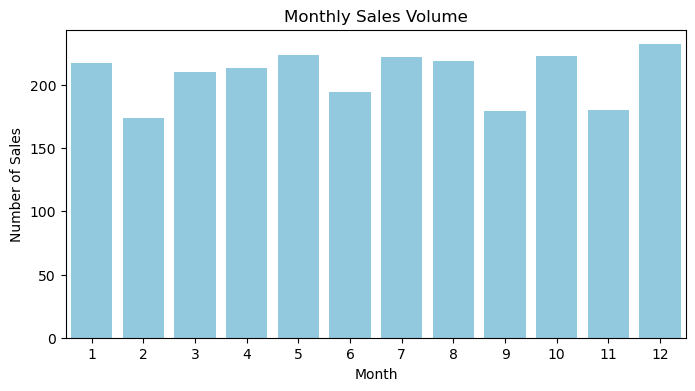

In [16]:
df_month = df_cleaned.withColumn("Month", month(to_date(col("Date Purchase"), "dd-MM-yyyy")))

# Count sales per month
df_month_pd = df_month.groupBy("Month").count().orderBy("Month").toPandas()

# Plot monthly trends
plt.figure(figsize=(8, 4))
sns.barplot(data=df_month_pd, x="Month", y="count", color="skyblue")
plt.title("Monthly Sales Volume")
plt.xlabel("Month")
plt.ylabel("Number of Sales")
plt.show()

# Rating Distribution

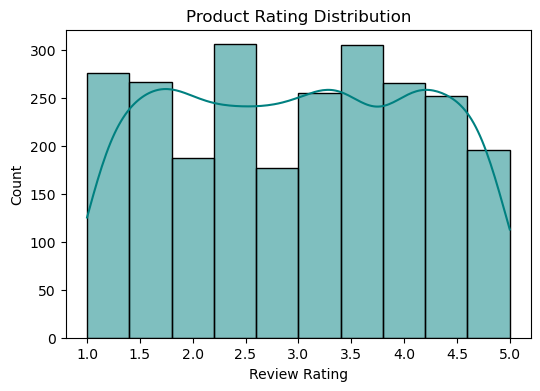

In [20]:
ratings_df = df_cleaned.select("Review Rating").toPandas()

plt.figure(figsize=(6, 4))
sns.histplot(ratings_df["Review Rating"], bins=10, kde=True, color="teal")
plt.title("Product Rating Distribution")
plt.show()

# ML-Like Insight — Classify Good Products

In [22]:
df_classified = df_cleaned.withColumn("Rating_Class", 
    when(col("Review Rating") >= 4.0, "Good")
    .when(col("Review Rating") >= 2.5, "Average")
    .otherwise("Poor")
)

df_classified.groupBy("Rating_Class").count().show()

+------------+-----+
|Rating_Class|count|
+------------+-----+
|     Average|  919|
|        Good|  659|
|        Poor|  909|
+------------+-----+



# ML-Like Feature Engineering for Products

In [23]:
df_ml = df_cleaned.select("Purchase Amount (USD)", "Review Rating", "Item Purchased")
df_ml.groupBy("Item Purchased").avg("Purchase Amount (USD)", "Review Rating").show()

+--------------+--------------------------+------------------+
|Item Purchased|avg(Purchase Amount (USD))|avg(Review Rating)|
+--------------+--------------------------+------------------+
|    Polo Shirt|        109.60975609756098|  2.81463413412978|
|    Flip-Flops|         291.2432432432432| 3.348648670557383|
|       T-shirt|        112.08928571428571|3.1607142644269124|
|        Bowtie|        219.55555555555554|2.8444444437821708|
|        Jacket|         162.2888888888889| 2.635555540190803|
|      Cardigan|        154.05263157894737| 3.057894742279722|
|      Sneakers|        109.43396226415095|2.9396226361112774|
|      Umbrella|        107.84615384615384| 3.098076921242934|
|        Kimono|        100.67272727272727| 2.887272724238309|
|         Tunic|        332.94117647058823| 2.535294114374647|
|           Tie|                   106.125| 2.987499991059303|
|          Belt|        154.12307692307692|2.9476922933871927|
|         Dress|         92.76744186046511|2.9674418416

## ✅ Project Complete

- Cleaned data written to Parquet
- Visuals saved in `/visualizations/`
- Simulated Kafka code included as Markdown
- ML-friendly insights built using Rating classification